In [120]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box
import glob
import os
from collections import Counter


In [99]:
shape_dir="/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/regions/shapes"
figures_dir="/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/domain_experiment/figures"
processed_data_dir="/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data"


In [78]:
delhi= gpd.read_file(shape_dir + "/delhi_ncr_region.geojson")
delhi_airshed = gpd.read_file(shape_dir + "/delhi_airshed.geojson")
uttar_pradesh = gpd.read_file(shape_dir + "/uttar_pradesh.geojson")
lucknow_airshed = gpd.read_file(shape_dir + "/lucknow_airshed.geojson")
west_bengal = gpd.read_file(shape_dir + "/west_bengal.geojson")
west_bengal_small_airshed = gpd.read_file(shape_dir + "/wb_small_airshed.geojson")

POINT (699550.2591179649 3179257.446215006)
POLYGON ((759550.2591179649 3119257.446215006, 759550.2591179649 3239257.446215006, 639550.2591179649 3239257.446215006, 639550.2591179649 3119257.446215006, 759550.2591179649 3119257.446215006))
                                            geometry
0  POLYGON ((77.64351 28.17356, 77.67088 29.25556...
POINT (1091485.988488935 2989293.90351032)
POLYGON ((1151485.988488935 2929293.90351032, 1151485.988488935 3049293.90351032, 1031485.9884889349 3049293.90351032, 1031485.9884889349 2929293.90351032, 1151485.988488935 2929293.90351032))
                                            geometry
0  POLYGON ((81.51984 26.33517, 81.58215 27.41152...


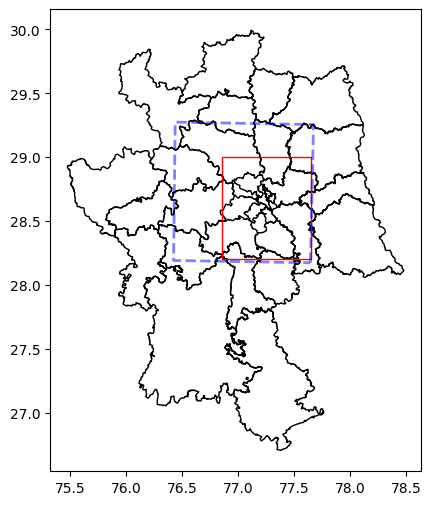

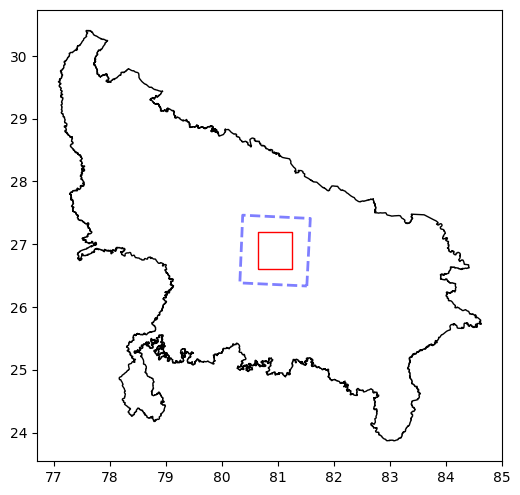

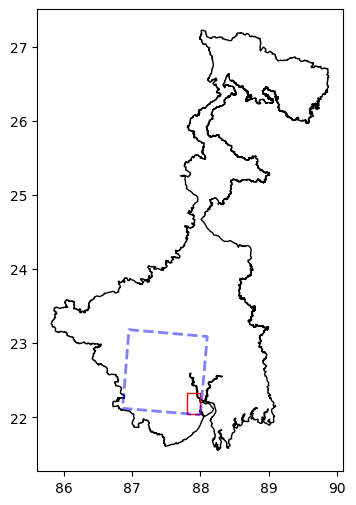

In [98]:
delhi = delhi.to_crs(epsg=4326) 
delhi_airshed = delhi_airshed.to_crs(epsg=4326)
lucknow_airshed = lucknow_airshed.to_crs(epsg=4326)
fig,ax=plt.subplots(figsize=(6,6))
delhi.boundary.plot(ax=ax,color='black', linewidth=1)
delhi_airshed.boundary.plot(ax=ax,color='red', linewidth=1)
half_size=60_000
delhi_airshed_projection = delhi_airshed.to_crs(epsg=32643)
delhi_projection= delhi.to_crs(epsg=32643)
delhi_airshed_centroid = delhi_projection.geometry.centroid.iloc[12]
print(delhi_airshed_centroid)
min_x,min_min_y,max_x,max_y = delhi_airshed_centroid.x - half_size, delhi_airshed_centroid.y - half_size, delhi_airshed_centroid.x + half_size, delhi_airshed_centroid.y + half_size
square_geometry = box(min_x, min_min_y, max_x, max_y)
print(square_geometry)
new_shape = gpd.GeoDataFrame(geometry=[square_geometry], crs=delhi_airshed_projection.crs)
new_shape = new_shape.to_crs(epsg=4326)
new_shape.boundary.plot(ax=ax,  color='blue', linewidth=2, linestyle='--', alpha=0.5)
print(new_shape)
new_shape.to_file(shape_dir + "/delhi_airshed_120.geojson", driver='GeoJSON')
fig.savefig(figures_dir + "/delhi_airshed_120.pdf", dpi=300, bbox_inches='tight')
fig,ax=plt.subplots(figsize=(6,6))
uttar_pradesh.boundary.plot(ax=ax,color='black', linewidth=1)
lucknow_airshed.boundary.plot(ax=ax,color='red', linewidth=1)
half_size=60_000
lucknow_airshed_projection = lucknow_airshed.to_crs(epsg=32643)
lucknow_projection= uttar_pradesh.to_crs(epsg=32643)
lucknow_airshed_centroid = lucknow_airshed_projection.geometry.centroid.iloc[0]
print(lucknow_airshed_centroid)
min_x,min_min_y,max_x,max_y = lucknow_airshed_centroid.x - half_size, lucknow_airshed_centroid.y - half_size, lucknow_airshed_centroid.x + half_size, lucknow_airshed_centroid.y + half_size
square_geometry = box(min_x, min_min_y, max_x, max_y)
print(square_geometry)
new_shape = gpd.GeoDataFrame(geometry=[square_geometry], crs=lucknow_airshed_projection.crs)
new_shape = new_shape.to_crs(epsg=4326)
new_shape.boundary.plot(ax=ax,  color='blue', linewidth=2, linestyle='--', alpha=0.5)
print(new_shape)
new_shape.to_file(shape_dir + "/lucknow_airshed_120.geojson", driver='GeoJSON')
fig.savefig(figures_dir + "/lucknow_airshed_120.pdf", dpi=300, bbox_inches='tight')
wb_proj = west_bengal.to_crs(epsg=32643)
airshed_proj = west_bengal_small_airshed.to_crs(epsg=32643)
minx, miny, maxx, maxy = airshed_proj.total_bounds
square_minx = maxx - 2*half_size
square_miny = miny
square_maxx = maxx
square_maxy = miny + 2*half_size
square_geom = box(square_minx, square_miny, square_maxx, square_maxy)
new_shape = gpd.GeoDataFrame(geometry=[square_geom], crs=airshed_proj.crs).to_crs(epsg=4326)
fig, ax = plt.subplots(figsize=(6, 6))
wb_proj.to_crs(4326).boundary.plot(ax=ax, color='black', linewidth=1)
airshed_proj.to_crs(4326).boundary.plot(ax=ax, color='red', linewidth=1)
new_shape.boundary.plot(ax=ax, color='blue', linewidth=2, linestyle='--', alpha=0.5)
plt.show()
new_shape.to_file(shape_dir + "/west_bengal_airshed_120.geojson", driver='GeoJSON')
fig.savefig(figures_dir + "/west_bengal_airshed_120.pdf", dpi=300, bbox_inches='tight')

In [117]:
delhi_images_dir = os.path.join(processed_data_dir, "delhi_airshed_120", "images")
lucknow_images_dir = os.path.join(processed_data_dir, "lucknow_airshed_120", "images")
west_bengal_images_dir = os.path.join(processed_data_dir, "west_bengal_airshed_120", "images")
delhi_images = glob.glob(os.path.join(delhi_images_dir, "*.tif"))
lucknow_airshed_images = glob.glob(os.path.join(lucknow_images_dir, "*.tif"))
west_bengal_images = glob.glob(os.path.join(west_bengal_images_dir, "*.tif"))
print("delhi_images",len(delhi_images))
print("lucknow_images",len(lucknow_airshed_images))
print("west_bengal_images",len(west_bengal_images))
delhi_labels_dir = os.path.join(processed_data_dir, "delhi_airshed_120", "labels")
lucknow_labels_dir = os.path.join(processed_data_dir, "lucknow_airshed_120", "labels")
west_bengal_labels_dir = os.path.join(processed_data_dir, "west_bengal_airshed_120", "labels")
delhi_labels = glob.glob(os.path.join(delhi_labels_dir, "*.txt"))
lucknow_labels = glob.glob(os.path.join(lucknow_labels_dir, "*.txt"))
west_bengal_labels = glob.glob(os.path.join(west_bengal_labels_dir, "*.txt"))
print("delhi_labels",len(delhi_labels))
print("lucknow_labels",len(lucknow_labels))
print("west_bengal_labels",len(west_bengal_labels))

delhi_images 2378
lucknow_images 2269
west_bengal_images 2045
delhi_labels 581
lucknow_labels 642
west_bengal_labels 239


In [138]:
delhi_train_dir = os.path.join(processed_data_dir, "delhi_airshed_120", "train")
lucknow_train_dir = os.path.join(processed_data_dir, "lucknow_airshed_120", "train")
west_bengal_train_dir = os.path.join(processed_data_dir, "west_bengal_airshed_120", "train")
os.makedirs(delhi_train_dir, exist_ok=True)
os.makedirs(lucknow_train_dir, exist_ok=True)
os.makedirs(west_bengal_train_dir, exist_ok=True)
delhi_train_dir_images_dir= os.path.join(delhi_train_dir, "images")
lucknow_train_dir_images_dir= os.path.join(lucknow_train_dir, "images")
west_bengal_train_dir_images_dir= os.path.join(west_bengal_train_dir, "images")
os.makedirs(delhi_train_dir_images_dir, exist_ok=True)
os.makedirs(lucknow_train_dir_images_dir, exist_ok=True)
os.makedirs(west_bengal_train_dir_images_dir, exist_ok=True)
delhi_train_dir_labels_dir= os.path.join(delhi_train_dir, "labels")
lucknow_train_dir_labels_dir= os.path.join(lucknow_train_dir, "labels")
west_bengal_train_dir_labels_dir= os.path.join(west_bengal_train_dir, "labels")
os.makedirs(delhi_train_dir_labels_dir, exist_ok=True)
os.makedirs(lucknow_train_dir_labels_dir, exist_ok=True)
os.makedirs(west_bengal_train_dir_labels_dir, exist_ok=True)    



In [139]:
import os
import glob
import random
import shutil
from collections import Counter

def random_images_and_labels(images_dir, labels_dir, save_dir, n=1000, seed=42):
    images_save_dir = os.path.join(save_dir, "images")
    labels_save_dir = os.path.join(save_dir, "labels")
    os.makedirs(images_save_dir, exist_ok=True)
    os.makedirs(labels_save_dir, exist_ok=True)

    all_images = glob.glob(os.path.join(images_dir, "*.tif"))
    random.seed(seed)
    random.shuffle(all_images)
    selected_images = all_images[:n]
    print(f"Selected {len(selected_images)} images from {images_dir}")

    selected_pairs = []
    class_counts = Counter()

    for img_path in selected_images:
        base = os.path.splitext(os.path.basename(img_path))[0]
        label_path = os.path.join(labels_dir, base + ".txt")
        # Always copy the image
        shutil.copy2(img_path, images_save_dir)
        if os.path.exists(label_path):
            shutil.copy2(label_path, labels_save_dir)
            selected_pairs.append((img_path, label_path))
            # Count classes
            with open(label_path, 'r') as f:
                for line in f:
                    if line.strip():
                        class_idx = int(line.strip().split()[0])
                        class_counts[class_idx] += 1

    print(f"Copied {len(selected_images)} images and {len(selected_pairs)} labels to {save_dir}")
    print(f"Class counts: {dict(class_counts)}")
    return selected_pairs

# Usage
print(delhi_train_dir)
delhi_pairs = random_images_and_labels(delhi_images_dir, delhi_labels_dir, delhi_train_dir, 1000)
lucknow_pairs = random_images_and_labels(lucknow_images_dir, lucknow_labels_dir, lucknow_train_dir, 1000)
west_bengal_pairs = random_images_and_labels(west_bengal_images_dir, west_bengal_labels_dir, west_bengal_train_dir, 1000)


/home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed_120/train
Selected 1000 images from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed_120/images
Copied 1000 images and 254 labels to /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/delhi_airshed_120/train
Class counts: {2: 811, 1: 52, 0: 2}
Selected 1000 images from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed_120/images
Copied 1000 images and 282 labels to /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/lucknow_airshed_120/train
Class counts: {1: 331, 0: 31, 2: 205}
Selected 1000 images from /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/west_bengal_airshed_120/images
Copied 1000 images and 119 labels to /home/rishabh.mondal/Brick-Kilns-project/ijcai_2025_kilns/data/processed_data/west_bengal_airshed_120/train
Clas

In [140]:
delhi_test_dir = os.path.join(processed_data_dir, "delhi_airshed_120", "test")
lucknow_test_dir = os.path.join(processed_data_dir, "lucknow_airshed_120", "test")
west_bengal_test_dir = os.path.join(processed_data_dir, "west_bengal_airshed_120", "test")

delhi_test_dir_images_dir = os.path.join(delhi_test_dir, "images")
lucknow_test_dir_images_dir = os.path.join(lucknow_test_dir, "images")
west_bengal_test_dir_images_dir = os.path.join(west_bengal_test_dir, "images")
os.makedirs(delhi_test_dir_images_dir, exist_ok=True)
os.makedirs(lucknow_test_dir_images_dir, exist_ok=True)
os.makedirs(west_bengal_test_dir_images_dir, exist_ok=True)

delhi_test_dir_labels_dir = os.path.join(delhi_test_dir, "labels")
lucknow_test_dir_labels_dir = os.path.join(lucknow_test_dir, "labels")
west_bengal_test_dir_labels_dir = os.path.join(west_bengal_test_dir, "labels")
os.makedirs(delhi_test_dir_labels_dir, exist_ok=True)
os.makedirs(lucknow_test_dir_labels_dir, exist_ok=True)
os.makedirs(west_bengal_test_dir_labels_dir, exist_ok=True)


In [141]:
train_image_files = glob.glob(os.path.join(delhi_train_dir_images_dir, "*.tif"))
train_basenames = set([os.path.splitext(os.path.basename(f))[0] for f in train_image_files])
import shutil

for img_path in delhi_images:
    base = os.path.splitext(os.path.basename(img_path))[0]
    if base not in train_basenames:
        # Copy image
        shutil.copy2(img_path, delhi_test_dir_images_dir)
        # Copy label if it exists
        label_path = os.path.join(delhi_labels_dir, base + ".txt")
        if os.path.exists(label_path):
            shutil.copy2(label_path, delhi_test_dir_labels_dir)


In [142]:
# Get train basenames for Lucknow
train_image_files = glob.glob(os.path.join(lucknow_train_dir_images_dir, "*.tif"))
train_basenames = set([os.path.splitext(os.path.basename(f))[0] for f in train_image_files])

# Copy images not in train to test
import shutil

for img_path in lucknow_airshed_images:
    base = os.path.splitext(os.path.basename(img_path))[0]
    if base not in train_basenames:
        # Copy image
        shutil.copy2(img_path, lucknow_test_dir_images_dir)
        # Copy label if it exists
        label_path = os.path.join(lucknow_labels_dir, base + ".txt")
        if os.path.exists(label_path):
            shutil.copy2(label_path, lucknow_test_dir_labels_dir)

In [143]:
# West Bengal: Set up test dirs (if not already)
west_bengal_test_dir = os.path.join(processed_data_dir, "west_bengal_airshed_120", "test")
west_bengal_test_dir_images_dir = os.path.join(west_bengal_test_dir, "images")
west_bengal_test_dir_labels_dir = os.path.join(west_bengal_test_dir, "labels")
os.makedirs(west_bengal_test_dir_images_dir, exist_ok=True)
os.makedirs(west_bengal_test_dir_labels_dir, exist_ok=True)

# Get train basenames for West Bengal
train_image_files = glob.glob(os.path.join(west_bengal_train_dir_images_dir, "*.tif"))
train_basenames = set([os.path.splitext(os.path.basename(f))[0] for f in train_image_files])

# Copy images not in train to test
import shutil

for img_path in west_bengal_images:
    base = os.path.splitext(os.path.basename(img_path))[0]
    if base not in train_basenames:
        # Copy image
        shutil.copy2(img_path, west_bengal_test_dir_images_dir)
        # Copy label if it exists
        label_path = os.path.join(west_bengal_labels_dir, base + ".txt")
        if os.path.exists(label_path):
            shutil.copy2(label_path, west_bengal_test_dir_labels_dir)


In [144]:
import os
import glob
from collections import Counter

def get_basenames_from_dir(images_dir):
    return set([os.path.splitext(os.path.basename(f))[0] for f in glob.glob(os.path.join(images_dir, "*.tif"))])

def count_classes_in_labels(labels_dir):
    class_counter = Counter()
    label_files = glob.glob(os.path.join(labels_dir, "*.txt"))
    for label_path in label_files:
        with open(label_path, 'r') as f:
            for line in f:
                if line.strip():
                    class_idx = int(line.strip().split()[0])
                    class_counter[class_idx] += 1
    return class_counter, len(label_files)

def summary_for_split(split_images_dir, split_labels_dir, split_name):
    image_files = glob.glob(os.path.join(split_images_dir, "*.tif"))
    n_images = len(image_files)
    class_counter, n_labels = count_classes_in_labels(split_labels_dir)
    print(f"\n{split_name.upper()} split:")
    print(f"  Images: {n_images}")
    print(f"  Labels: {n_labels}")
    print(f"  Class counts: {dict(class_counter)}")
    return get_basenames_from_dir(split_images_dir)

def check_common(train_basenames, test_basenames, split_name):
    common = train_basenames & test_basenames
    if common:
        print(f"\nWARNING: {len(common)} common files found in {split_name} train and test!")
        print("Examples:", list(common)[:5])
    else:
        print(f"\nNo common image files between {split_name} train and test.")

# Example for Delhi, repeat for other airsheds
print("="*40)
print("DELHI AIRSHED SPLIT CHECK")

delhi_train_basenames = summary_for_split(delhi_train_dir_images_dir, delhi_train_dir_labels_dir, "Delhi Train")
delhi_test_basenames = summary_for_split(delhi_test_dir_images_dir, delhi_test_dir_labels_dir, "Delhi Test")
check_common(delhi_train_basenames, delhi_test_basenames, "Delhi")

# Repeat for Lucknow
print("\n" + "="*40)
print("LUCKNOW AIRSHED SPLIT CHECK")
lucknow_train_basenames = summary_for_split(lucknow_train_dir_images_dir, lucknow_train_dir_labels_dir, "Lucknow Train")
lucknow_test_basenames = summary_for_split(lucknow_test_dir_images_dir, lucknow_test_dir_labels_dir, "Lucknow Test")
check_common(lucknow_train_basenames, lucknow_test_basenames, "Lucknow")

# Repeat for West Bengal
print("\n" + "="*40)
print("WEST BENGAL AIRSHED SPLIT CHECK")
wb_train_basenames = summary_for_split(west_bengal_train_dir_images_dir, west_bengal_train_dir_labels_dir, "West Bengal Train")
wb_test_basenames = summary_for_split(west_bengal_test_dir_images_dir, west_bengal_test_dir_labels_dir, "West Bengal Test")
check_common(wb_train_basenames, wb_test_basenames, "West Bengal")


DELHI AIRSHED SPLIT CHECK

DELHI TRAIN split:
  Images: 1000
  Labels: 254
  Class counts: {2: 811, 1: 52, 0: 2}

DELHI TEST split:
  Images: 1378
  Labels: 327
  Class counts: {2: 926, 1: 55, 0: 3}

No common image files between Delhi train and test.

LUCKNOW AIRSHED SPLIT CHECK

LUCKNOW TRAIN split:
  Images: 1000
  Labels: 282
  Class counts: {2: 205, 1: 331, 0: 31}

LUCKNOW TEST split:
  Images: 1269
  Labels: 360
  Class counts: {1: 450, 2: 275, 0: 47}

No common image files between Lucknow train and test.

WEST BENGAL AIRSHED SPLIT CHECK

WEST BENGAL TRAIN split:
  Images: 1000
  Labels: 119
  Class counts: {1: 104, 2: 158, 0: 2}

WEST BENGAL TEST split:
  Images: 1045
  Labels: 120
  Class counts: {2: 175, 1: 136, 0: 7}

No common image files between West Bengal train and test.
